In [1]:
import torch
import torch.nn.functional as F
import requests
import os
import random
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import tqdm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

/home/xerneas/jupyter-env/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = "input.txt"
if not os.path.exists(path):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    resp = requests.get(url, stream=True)
    total = int(resp.headers.get("Content-Length", 0))
    with open(path, "wb") as f:
        bar = tqdm(total=total, unit="B", unit_scale=True, desc="input.txt")
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
        bar.close()

with open(path) as f:
    text = f.read()

# print(len(text)
# print(text[:500])

In [3]:
if (device := torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")):
    print(f"Using device: {device}")

block_size = 64
epochs = 5000
iters = 5000
eval_iters = 100
lr = 0.0001
embd = 384
batch=1024
dropout = 0.2
num_heads = 8
num_blocks = 6

Using device: cuda


In [4]:
chars = sorted(set(text))
vocab_size = len(chars)
print(chars)
def stoi(x):
    return chars.index(x) if isinstance(x, str) else chars[x]
_stoi = {c: i for i, c in enumerate(chars)}
def itos(x):
    return _stoi[x] if isinstance(x, str) else chars[x]

print("itos:", itos(1), itos(2), itos(3), itos(0), "\n")
print("stoi:", stoi('.'), stoi('a'), stoi('b'), stoi('c'), "/n")

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
itos:   ! $ 
 

stoi: 8 39 40 41 /n


In [5]:
def build_dataset(data):
    X, Y = [], []
    for i in range(len(data) - block_size):
        X.append(data[i : i + block_size])
        Y.append(data[i+1 : i + block_size + 1])
    X = torch.stack(X)
    Y = torch.stack(Y)
    return X, Y

In [6]:
data = torch.tensor([stoi(c) for c in text])
n = int(0.9 * len(data))
train_data = data[:n].to(device)     # ~8.5 MB, trivial — keep on GPU
val_data   = data[n:].to(device)

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch,))
    x = torch.stack([d[i   : i+block_size]   for i in ix])
    y = torch.stack([d[i+1 : i+block_size+1] for i in ix])
    return x, y


In [7]:
# data = torch.tensor([stoi(c) for c in text])
# X, Y = build_dataset(data)
# n = X.shape[0]
# Xtr, Ytr = X[:int(n*0.9)], Y[:int(n*0.9)]
# Xdev, Ydev = X[int(n*0.9):], Y[int(n*0.9):]
# Xtr, Ytr = [x.to(device) for x in (Xtr, Ytr)]
# Xdev, Ydev = [x.to(device) for x in (Xdev, Ydev)]
# print(X.shape, Y.shape)
# print(Xtr.shape, Ytr.shape)
# print(Xdev.shape, Ydev.shape)

# trainds = torch.utils.data.TensorDataset(Xtr.cpu(), Ytr.cpu())
# traindl = DataLoader(
#     dataset=trainds,
#     batch_size=batch,
#     pin_memory=True,
#     shuffle=True,
#     num_workers=4,
#     prefetch_factor=8
# )

In [8]:
class Head(nn.Module):
    def __init__(self, head_size, embd):
        super().__init__()
        self.key = nn.Linear(embd, head_size, bias=False)
        self.query = nn.Linear(embd, head_size, bias=False)
        self.value = nn.Linear(embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.drop = nn.Dropout(dropout)
        
    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * C**-0.5 #BTC @ BCT => BTT
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.drop(wei)
        out = wei @ v
        return out
        

In [9]:
class multihead(nn.Module):
    def __init__(self, num_heads, head_size, embd):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, embd) for _ in range(num_heads)])
        self.proj = nn.Linear(embd, embd)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        stack = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.drop(self.proj(stack))

In [10]:
class feedForward(nn.Module):
    def __init__(self, embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embd, embd),
            nn.ReLU(),
            nn.Linear(embd, embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

In [11]:
class attenB(nn.Module):
    def __init__(self, embd, nhead):
        super().__init__()
        self.ffw = feedForward(embd)
        self.sa = multihead(nhead, embd//nhead, embd)
        self.ln1 = nn.LayerNorm(embd)
        self.ln2 = nn.LayerNorm(embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffw(self.ln2(x))
        return x

In [12]:
class LM(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, embd)
        self.position_embedding = nn.Embedding(block_size, embd)
        #to change
        self.atten = nn.Sequential(
            *[attenB(embd, num_heads) for _ in range(num_blocks)]
        )
        self.ln = nn.LayerNorm(embd)
        self.lm = nn.Linear(embd, vocab_size)
        self.ffw = feedForward(embd)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.atten(x)
        return self.lm(self.ln(x))
    

In [13]:
model = LM().to(device)
model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.99995)

In [14]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            Xb, Yb = get_batch(split)
            logits = model(Xb)
            losses[k] = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1))
        out[split] = losses.mean().item()
    model.train()
    return out

In [15]:
model.train()
pbar = tqdm(range(iters), desc="train")
t_loss = []
for step in pbar:
    Xb, Yb = get_batch('train')
    logits = model(Xb)
    loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1))
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    scheduler.step()
    t_loss.append(loss.item())
    pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
    if step % eval_iters == 0:
        print(step, loss.item(), scheduler.get_last_lr()[0])
        # print(estimate_loss())


train:   0%|          | 1/5000 [00:01<2:06:14,  1.52s/it, loss=4.3722, lr=1.00e-04]

0 4.372194290161133 9.999500000000001e-05


train:   2%|▏         | 101/5000 [00:31<24:43,  3.30it/s, loss=2.5692, lr=9.95e-05]

100 2.569225549697876 9.949626041942441e-05


train:   4%|▍         | 201/5000 [01:02<24:18,  3.29it/s, loss=2.4104, lr=9.90e-05]

...

train:  96%|█████████▌| 4801/5000 [24:22<01:00,  3.29it/s, loss=1.3597, lr=7.87e-05]

4800 1.3596973419189453 7.865838099991829e-05


train:  98%|█████████▊| 4901/5000 [24:53<00:30,  3.29it/s, loss=1.3433, lr=7.83e-05]

4900 1.343332290649414 7.8266060904427e-05


train: 100%|██████████| 5000/5000 [25:23<00:00,  3.28it/s, loss=1.3498, lr=7.79e-05]


In [16]:
print(estimate_loss())

{'train': 1.260386347770691, 'val': 1.5182379484176636}


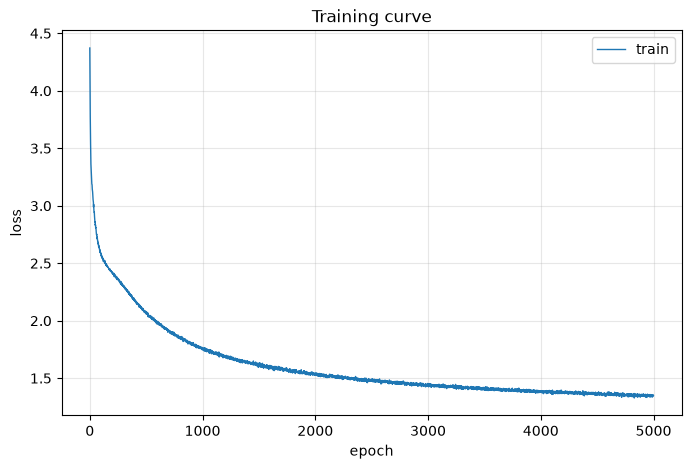

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(t_loss)), t_loss, label='train', linewidth=1)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
model.eval()
for i in range(10):
    out = []
    context = [0] * block_size
    for _ in range(50):
        logits = model(torch.tensor([context], device=device))
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos(ix))
    print(''.join(out))

WARWICK:
We goes and enough before I am.

CLARENCE
COMINIUS:
What we he?

JULIET:
Go to our fellow,
G
GLOUCESTER:
O enviousion, you be conquired of affa
BRAKENBURY:
But thou wilt thy presence is this pri
EDWARD:
Monder, exclaim?

ANGELO:
Nor, I have, by 
FRIAR LAURENCE:
More you, Lartius, how you high to
MERCUTIO:
Well, help it. What is too?' the conduct
PRINCE EDWARD:
With her place, being why, and am I
HASTINGS:
Stand false of go.

LEONTES:
Ghost of th
MERCUTIO:
Why, then all the deceives of an strengt
